In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, metrics
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import StratifiedKFold, train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import tensorflow as tf
print("Devices:", tf.config.list_physical_devices())


2025-12-18 17:15:17.624466: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-18 17:15:17.640856: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766058317.659803 2384620 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766058317.665712 2384620 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766058317.680453 2384620 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2025-12-18 17:15:20.112177: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-12-18 17:15:20.112202: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2025-12-18 17:15:20.112220: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2025-12-18 17:15:20.112226: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-12-18 17:15:20.112230: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: rgitbt-PowerEdge-R750
2025-12-18 17:15:20.112233: I external/local_xla/xla/stream_execu

In [2]:
IMG_SIZE = 260

def load_image(path):
    img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = img_to_array(img)
    return preprocess_input(img)

df = pd.read_csv("Breastcancer.csv")

df["path"] = "/home/rgitbt/sagar/codebook/dataset/" + df["File_Name"]

X_images = np.array([load_image(p) for p in df["path"]])

X_clinical = df[["Age", "BIRADS category", "Breast_density_category"]].values.astype("float32")

y = df["Label"].values


In [3]:
Ximg_trainval, Ximg_test, Xclin_trainval, Xclin_test, y_trainval, y_test = train_test_split(
    X_images, X_clinical, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [4]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB2

def build_image_model():
    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    base = EfficientNetB2(
        include_top=False,
        weights="imagenet",
        pooling="avg"
    )
    base.trainable = False

    x = base(img_input)
    x = layers.Dense(256, activation="relu")(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(img_input, output)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model

In [5]:
def build_clinical_model():
    clin_input = layers.Input(shape=(3,))
    x = layers.Dense(32, activation="relu")(clin_input)
    x = layers.Dense(16, activation="relu")(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(clin_input, output)
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )
    return model


In [6]:
def build_hybrid_model():
    # Image branch
    img_input = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = EfficientNetB2(
        include_top=False,
        weights="imagenet",
        input_tensor=img_input
    )
    base.trainable = False

    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(256, activation="relu")(x)

    # Clinical branch
    clin_input = layers.Input(shape=(3,))
    c = layers.Dense(32, activation="relu")(clin_input)

    # Fusion
    combined = layers.concatenate([x, c])
    combined = layers.Dense(64, activation="relu")(combined)
    output = layers.Dense(1, activation="sigmoid")(combined)

    model = models.Model(
        inputs=[img_input, clin_input],
        outputs=output
    )

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            metrics.AUC(name='auc'),
            metrics.Precision(name='precision'),
            metrics.Recall(name='recall'),
            metrics.TruePositives(name='tp'),
            metrics.FalsePositives(name='fp'),
            metrics.TrueNegatives(name='tn'),
            metrics.FalseNegatives(name='fn')
        ]
    )
    model.summary()
    return model


In [7]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores = []
fold = 1

for train_idx, val_idx in kfold.split(Ximg_trainval, y_trainval):
    print(f"\n🔁 Fold {fold}")

    Ximg_train = Ximg_trainval[train_idx]
    Ximg_val   = Ximg_trainval[val_idx]

    Xclin_train = Xclin_trainval[train_idx]
    Xclin_val   = Xclin_trainval[val_idx]

    y_train = y_trainval[train_idx]
    y_val   = y_trainval[val_idx]

    model = build_hybrid_model()

    checkpoint = ModelCheckpoint(
        f"best_model_fold{fold}.keras",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        [Ximg_train, Xclin_train],
        y_train,
        validation_data=([Ximg_val, Xclin_val], y_val),
        epochs=20,
        batch_size=16,
        callbacks=[checkpoint],
        verbose=1
    )

    best_auc = max(history.history["val_auc"])
    auc_scores.append(best_auc)

    print(f"✅ Fold {fold} Best AUC: {best_auc:.4f}")
    fold += 1



🔁 Fold 1


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 260, 260,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 260, 260,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 260, 260,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 8,147,962 (31.08 MB)

 Trainable params: 379,393 (1.45 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 260, 260,  │          0 │ input_layer_8[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 260, 260,  │          7 │ rescaling_8[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_9         │ (None, 260, 260,  │          0 │ normalization_4[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_9[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 8,147,962 (31.08 MB)

 Trainable params: 379,393 (1.45 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.8829 - auc: 0.6612 - fn: 94.1944 - fp: 15.0000 - loss: 0.3805 - precision: 0.1925 - recall: 0.0538 - tn: 1045.6459 - tp: 5.0556
Epoch 1: val_auc improved from -inf to 0.97360, saving model to best_model_fold5.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 98s 600ms/step - accuracy: 0.8831 - auc: 0.6620 - fn: 94.7310 - fp: 15.0000 - loss: 0.3797 - precision: 0.1951 - recall: 0.0541 - tn: 1052.7931 - tp: 5.1586 - val_accuracy: 0.9580 - val_auc: 0.9736 - val_fn: 24.0000 - val_fp: 0.0000e+00 - val_loss: 0.1323 - val_precision: 1.0000 - val_recall: 0.5000 - val_tn: 524.0000 - val_tp: 24.0000
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.9590 - auc: 0.9555 - fn: 42.8750 - fp: 1.5694 - loss: 0.1261 - precision: 0.9674 - recall: 0.4880 - tn: 1067.2570 - tp: 48.1944
Epoch 2: val_auc improved from 0.97360 to 0.99944, saving model to best_model_fold5.keras
144/144 ━━━━━━━━━━━━━━━━━━━━ 83s 580ms/step - accuracy: 0.9591 -

In [8]:
from tensorflow.keras.models import load_model

best_fold = np.argmax(auc_scores) + 1
print("🏆 Best Fold:", best_fold)

best_model = load_model(f"best_model_fold{best_fold}.keras")

best_model.save("best_hybrid_model_overall.keras")


🏆 Best Fold: 3


In [9]:
print("\n📊 Cross-Validation Results")
print(f"Mean AUC: {np.mean(auc_scores):.4f}")
print(f"Std  AUC: {np.std(auc_scores):.4f}")



📊 Cross-Validation Results
Mean AUC: 0.9935
Std  AUC: 0.0086


In [10]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, f1_score, matthews_corrcoef
)

# Probabilities
y_prob = best_model.predict([Ximg_test, Xclin_test]).ravel()
y_pred = (y_prob > 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics_dict = {
    "Accuracy": (tp + tn) / (tp + tn + fp + fn),
    "AUC": roc_auc_score(y_test, y_prob),
    "Sensitivity (Recall)": tp / (tp + fn),
    "Specificity": tn / (tn + fp),
    "Precision": tp / (tp + fp),
    "F1-score": f1_score(y_test, y_pred),
    "MCC": matthews_corrcoef(y_test, y_pred)
}

print("\n🧪 Final Test Metrics")
for k, v in metrics_dict.items():
    print(f"{k:20s}: {v:.4f}")

print("\n📋 Classification Report")
print(classification_report(y_test, y_pred,
      target_names=["Non-Cancer", "Cancer"]))


23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 856ms/step

🧪 Final Test Metrics
Accuracy            : 0.9930
AUC                 : 0.9887
Sensitivity (Recall): 0.9500
Specificity         : 0.9970
Precision           : 0.9661
F1-score            : 0.9580
MCC                 : 0.9542

📋 Classification Report
              precision    recall  f1-score   support

  Non-Cancer       1.00      1.00      1.00       656
      Cancer       0.97      0.95      0.96        60

    accuracy                           0.99       716
   macro avg       0.98      0.97      0.98       716
weighted avg       0.99      0.99      0.99       716



In [11]:
from sklearn.utils import resample

def bootstrap_auc(y_true, y_prob, n_boot=2000):
    aucs = []
    for _ in range(n_boot):
        idx = resample(range(len(y_true)))
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_prob[idx]))
    return np.percentile(aucs, [2.5, 97.5])

ci_low, ci_high = bootstrap_auc(y_test, y_prob)
print(f"AUC 95% CI: [{ci_low:.3f}, {ci_high:.3f}]")

AUC 95% CI: [0.965, 1.000]


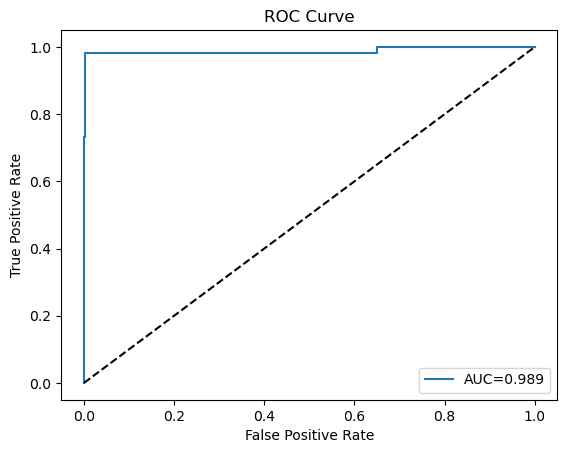

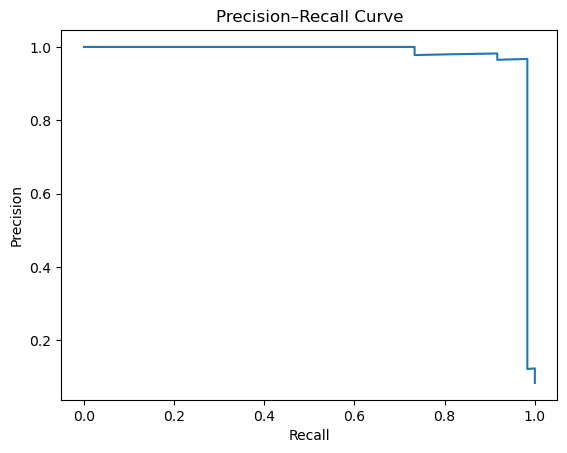

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC={metrics_dict['AUC']:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

In [13]:
image_model = build_image_model()
clin_model = build_clinical_model()
hybrid_model = build_hybrid_model()


image_model.fit(
    Ximg_train, y_train,
    validation_data=(Ximg_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

clin_model.fit(
    Xclin_train, y_train,
    validation_data=(Xclin_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

hybrid_model.fit(
    [Ximg_train, Xclin_train], y_train,
    validation_data=([Ximg_val, Xclin_val], y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

#Ablation Study
y_prob_image = image_model.predict(Ximg_test).ravel()  #imageonly
y_prob_clin = clin_model.predict(Xclin_test).ravel()   #Clinical
y_prob_hybrid = hybrid_model.predict([Ximg_test, Xclin_test]).ravel()    #Hybrid


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_12        │ (None, 260, 260,  │          0 │ input_layer_13[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_6     │ (None, 260, 260,  │          7 │ rescaling_12[0][… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_13        │ (None, 260, 260,  │          0 │ normalization_6[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 261, 261,  │          0 │ rescaling_13[0][… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 130, 130,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 130, 130,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 130, 130,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 130, 130,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 130, 130,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 130, 130,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 130, 130,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 130, 130,  │        512 │ block1a_se_excit

 Total params: 8,147,962 (31.08 MB)

 Trainable params: 379,393 (1.45 MB)

 Non-trainable params: 7,768,569 (29.63 MB)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 81s 478ms/step - accuracy: 0.8888 - auc: 0.4992 - loss: 0.3294 - val_accuracy: 0.9161 - val_auc: 0.4655 - val_loss: 0.3010
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 65s 448ms/step - accuracy: 0.9132 - auc: 0.5934 - loss: 0.2955 - val_accuracy: 0.9161 - val_auc: 0.4527 - val_loss: 0.3253
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 65s 451ms/step - accuracy: 0.9133 - auc: 0.6317 - loss: 0.2892 - val_accuracy: 0.9161 - val_auc: 0.4792 - val_loss: 0.3060
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 65s 452ms/step - accuracy: 0.9061 - auc: 0.6375 - loss: 0.3009 - val_accuracy: 0.9161 - val_auc: 0.4561 - val_loss: 0.3171
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 65s 451ms/step - accuracy: 0.9124 - auc: 0.7190 - loss: 0.2744 - val_accuracy: 0.9161 - val_auc: 0.4663 - val_loss: 0.3203
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 65s 454ms/step - accuracy: 0.9196 - auc: 0.6987 - loss: 0.2597 - val_accuracy: 0.9161 - val_auc: 0.5034 - val_loss: 0.3216
Epoch 7/20
144/144 ━━━

In [14]:
print("Image AUC:", bootstrap_auc(y_test, y_prob_image))
print("Clinical AUC:", bootstrap_auc(y_test, y_prob_clin))
print("Hybrid AUC:", bootstrap_auc(y_test, y_prob_hybrid))


Image AUC: [0.40520932 0.55827706]
Clinical AUC: [0.95696141 0.99987993]
Hybrid AUC: [0.97270261 1.        ]


In [15]:
pip install delong


ERROR: Could not find a version that satisfies the requirement delong (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for delong
Note: you may need to restart the kernel to use updated packages.


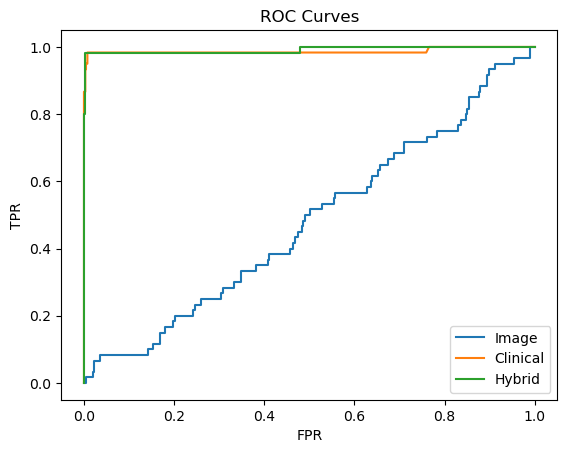

In [16]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

def plot_roc(y, prob, label):
    fpr, tpr, _ = roc_curve(y, prob)
    plt.plot(fpr, tpr, label=label)

plt.figure()
plot_roc(y_test, y_prob_image, "Image")
plot_roc(y_test, y_prob_clin, "Clinical")
plot_roc(y_test, y_prob_hybrid, "Hybrid")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.title("ROC Curves")
plt.show()


In [17]:
from delong import delong_roc_test

p_val_img_vs_hybrid = delong_roc_test(
    y_test,
    y_prob_image,
    y_prob_hybrid
)

p_val_clin_vs_hybrid = delong_roc_test(
    y_test,
    y_prob_clin,
    y_prob_hybrid
)

print("Image vs Hybrid p-value:", p_val_img_vs_hybrid)
print("Clinical vs Hybrid p-value:", p_val_clin_vs_hybrid)


Image vs Hybrid p-value: 0.05762167043354749
Clinical vs Hybrid p-value: 0.932543368322222


In [18]:
from delong import delong_roc_test

p_value = delong_roc_test(
    y_test,
    y_prob_image,
    y_prob_hybrid
)

print("DeLong p-value:", p_value)


DeLong p-value: 0.05762167043354749


In [49]:
import tensorflow as tf

def grad_cam_hybrid(model, img, clin, layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, pred = grad_model([img, clin])
        loss = pred[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


In [51]:
import matplotlib.pyplot as plt
import tensorflow as tf

def overlay_heatmap(image, heatmap, alpha=0.4):
    heatmap = tf.image.resize(heatmap[..., None], (IMG_SIZE, IMG_SIZE))
    heatmap = tf.squeeze(heatmap).numpy()

    plt.imshow(image.astype("uint8"))
    plt.imshow(heatmap, cmap="jet", alpha=alpha)
    plt.axis("off")


In [52]:
import matplotlib.pyplot as plt
import tensorflow as tf

def overlay_heatmap(image, heatmap, alpha=0.4):
    heatmap = tf.image.resize(heatmap[..., None], (IMG_SIZE, IMG_SIZE))
    heatmap = tf.squeeze(heatmap).numpy()

    plt.imshow(image.astype("uint8"))
    plt.imshow(heatmap, cmap="jet", alpha=alpha)
    plt.axis("off")


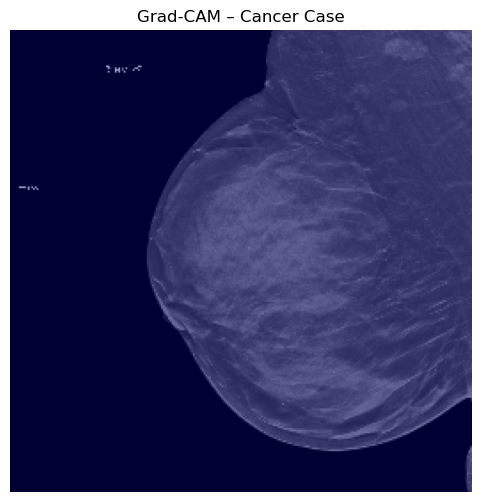

<Figure size 640x480 with 0 Axes>

In [53]:
idx = np.where(y_test == 1)[0][0]  # pick cancer sample

heatmap = gradcam_hybrid(
    best_model,
    Ximg_test[idx],
    Xclin_test[idx],
    layer_name="top_conv"
)

plt.figure(figsize=(6,6))
overlay_heatmap(Ximg_test[idx], heatmap)
plt.title("Grad-CAM – Cancer Case")
plt.show()
plt.savefig("gradcam.png")


In [67]:
img = load_image("/home/rgitbt/sagar/codebook/dataset/0492_00.png")

prob = image_model.predict(img)[0][0]

#prob = best_model.predict([img])
print("Cancer probability:", prob[0])


ValueError: as_list() is not defined on an unknown TensorShape.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Cancer Probability: 0.9999995


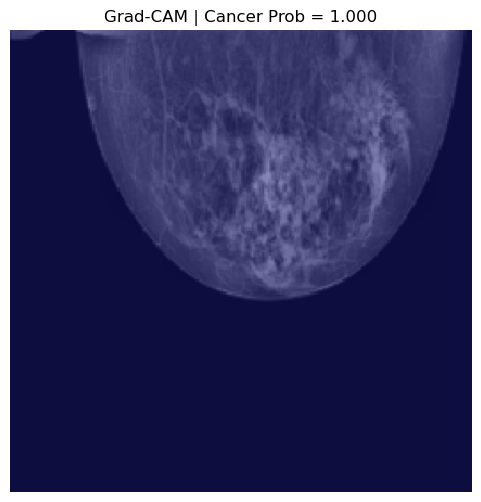

In [70]:
# Path to any mammogram PNG
img_path = "/home/rgitbt/sagar/codebook/14769221/BreastCancer_Benign/BreastCancer_Benign/20586908(52).png"

def load_clinical(age, birads, density):
    return np.array([[age, birads, density]], dtype="float32")


# Load inputs
Ximg = load_single_image(img_path)
Xclin = load_clinical(age=44, birads=6, density=3)

# Predict
prob = model.predict([Ximg, Xclin])[0][0]
print("Cancer Probability:", prob)

# Generate Grad-CAM
heatmap = grad_cam_hybrid(
    model,
    Ximg,
    Xclin,
    layer_name="top_conv"   # EfficientNet last conv layer
)

# Display
plt.figure(figsize=(6,6))
overlay_heatmap(Ximg[0], heatmap)
plt.title(f"Grad-CAM | Cancer Prob = {prob:.3f}")
plt.show()
